In [6]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.utils.data import get_pkg_data_filename
from astropy.io import fits
%matplotlib inline

## 1. Load a LIGO/Virgo Flat HEALPix Sky Map 
Example: S251112cm

In [ ]:
# Read the map
m, header = hp.read_map('bayestar.fits', h=True, verbose=False)
header = dict(header)
print(f"Nside = {header['NSIDE']}, Ordering = {header['ORDERING']}")
print(f"Number of pixels = {len(m):,}")

Nside = 512, Ordering = NESTED
Number of pixels = 3,145,728


/var/folders/sy/4t6z4zzj41n_hpwrc85v_4hm0000gn/T/ipykernel_9596/1635846445.py:2: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m, header = hp.read_map('bayestar.fits', h=True, verbose=False)


In [16]:
m

array([1.61449317e-13, 1.65103416e-13, 3.80432441e-13, ...,
       2.62669660e-13, 2.28974739e-13, 2.48964114e-13], dtype='>f8')

## 2. Understanding HEALPix Map Orderings

HEALPix maps can be stored in two different orderings:

- **RING ordering**: Pixels are arranged in horizontal rings of constant latitude, numbered from north to south pole
- **NESTED ordering**: Pixels follow a hierarchical quad-tree structure, where nearby pixels have nearby indices. **Best for computation, indexing, and hierarchical methods**


In [9]:
nside = hp.get_nside(m)        # or header['NSIDE']
npix = hp.nside2npix(nside)
print(f"Nside: {nside}")
print(f"Total pixels on the sky: {npix:,}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.4f} deg²")

Nside: 512
Total pixels on the sky: 3,145,728
Pixel area: 0.0131 deg²


$$N_{\text{pix}} = 12 \, \text{NSIDE}^2$$

## 3. Visualize the Sky Map (Mollweide Projection)

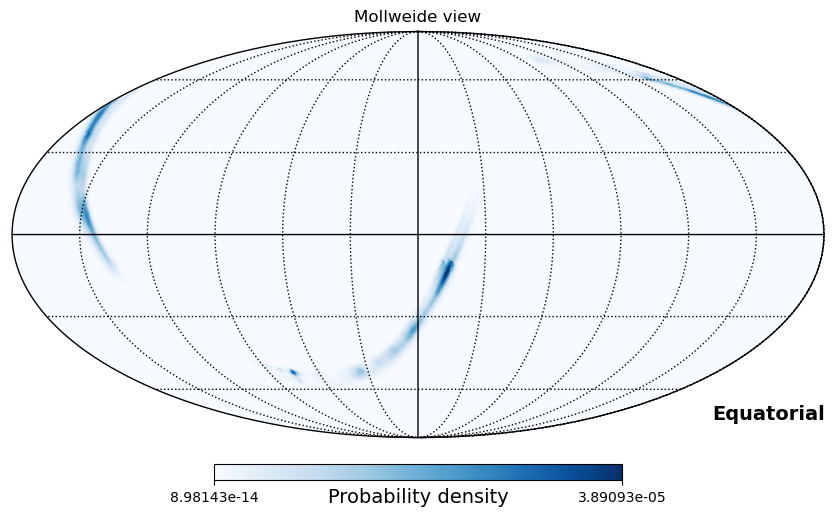

In [23]:
hp.mollview(m, unit="Probability density", coord='C', cmap='Blues')
hp.graticule()
plt.show()

### Careful about rotated axes!! Zero RA point is at the center of the map

## 4. Find the Highest-Probability Pixel & Convert to Sky Coordinates

In [13]:
ipix_max = np.argmax(m)
theta, phi = hp.pix2ang(nside, ipix_max)
ra_deg = np.degrees(phi)
dec_deg = 90 - np.degrees(theta)

print(f"Highest probability pixel index: {ipix_max}")
print(f"RA, Dec = {ra_deg:.4f}°, {dec_deg:.4f}°")

Highest probability pixel index: 1940405
RA, Dec = 346.8164°, -13.4781°


## 5. Compute Credible Levels (50%, 90%, etc.)

In [ ]:
# Sort pixels by probability density (descending)
sorted_prob = np.sort(m)[::-1]

# Cumulative probability
cumsum = np.cumsum(sorted_prob)
cumsum /= cumsum[-1]  # normalize to 1

print(f"Number of pixels in 90% region: {np.count_nonzero(cumsum <= 0.90)}")
print(f"The area of the 90% credible region is {np.count_nonzero(cumsum <= 0.90) * hp.nside2pixarea(nside, degrees=True):.4f} deg²")

Number of pixels in 90% region: 93049
The area of the 90% credible region is 1220.2412 deg²


In [ ]:
def get_credible_level(ra, dec, skymap_data, nside):
    """
    Get the credible level for a given RA and Dec position.
    
    Parameters:
    ra: Right Ascension in degrees
    dec: Declination in degrees
    skymap_data: HEALPix probability map
    nside: HEALPix nside parameter
    
    Returns:
    Credible level as a percentage
    """
    # Convert RA, Dec to theta, phi
    theta_query = np.radians(90 - dec)
    phi_query = np.radians(ra)
    
    # Get pixel index
    ipix_query = hp.ang2pix(nside, theta_query, phi_query)
    
    # Get probability at this pixel
    prob_at_pixel = skymap_data[ipix_query]
    
    # Calculate credible level
    sorted_prob_desc = np.sort(skymap_data)[::-1]
    cumsum_prob = np.cumsum(sorted_prob_desc)
    cumsum_prob /= cumsum_prob[-1]

    # I ASSIGNED TO EACH PIXEL THE CREDIBLE LEVEL BASED ON ITS PROBABILITY DENSITY, AFTER SORTING
    
    # Find where this probability falls in the sorted array
    credible_level = cumsum_prob[sorted_prob_desc >= prob_at_pixel][-1] * 100
    
    return credible_level, prob_at_pixel

# Example usage: check the highest probability pixel
ra_test = 180
dec_test = 55
cl, prob = get_credible_level(ra_test, dec_test, m, nside)
print(f"RA={ra_test:.4f}°, Dec={dec_test:.4f}°")
print(f"Probability density: {prob:.6e}")
print(f"Credible level: {cl:.2f}%")

RA=180.0000°, Dec=55.0000°
Probability density: 6.402603e-06
Credible level: 73.88%


## 7. Downgrade to Lower Resolution

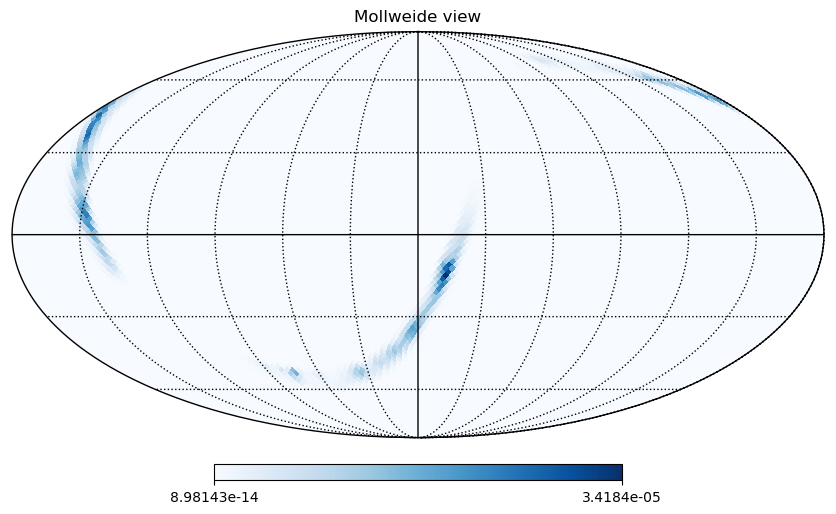

In [24]:
nside_low = 32
m_low = hp.ud_grade(m, nside_out=nside_low)  # averages probability density correctly

hp.mollview(m_low,cmap='Blues')
hp.graticule()
plt.show()

## 8. Integrated probability inside a circle

In [31]:
ra_test = 180
dec_test = 55
theta = np.radians(90 - dec_test)
phi = np.radians(ra_test)
radius = np.radians(5)  # example radius of 5 degrees
xyz = hp.ang2vec(theta, phi)
ipix_disc = hp.query_disc(nside, xyz, radius)
print(f"{m[ipix_disc].sum()*100:.2f}%")

4.84%


## 9. Integrated probability inside a polygon

In [30]:
# Convert polygon vertices from RA, Dec to Cartesian coordinates
# Create a square polygon centered at ra_test, dec_test with side 10 degrees
half_side = 5  # half of 10 degrees
vertices_radec = [[ra_test - half_side, dec_test - half_side], 
                  [ra_test + half_side, dec_test - half_side], 
                  [ra_test + half_side, dec_test + half_side], 
                  [ra_test - half_side, dec_test + half_side]]

xyz = np.array([hp.ang2vec(np.radians(90 - dec), np.radians(ra)) 
                for ra, dec in vertices_radec])
ipix_poly = hp.query_polygon(nside, xyz)
print(f"{m[ipix_poly].sum()*100:.2f}%")

3.39%


# Multi-order resolution maps

Each region of the sky is divide in sub-regions, and the process is done iteretively until it's reached a resolution of the same spatial scale of the variations of the map in that region of the sky. Coarser grid where the probability has a smoother change, finer where more information is contained

<img src="images/healpix-adaptive-mesh.svg" alt="Swift and Fermi mission comparison" width="300"/>

Then we have 2 info: the level of resolution of the sub-grid (given by nside) and the order of the pixel inside that sub-grid. This is compressed in a single index

$ uniq = ipix + 4 * nside^2 $   

In [64]:
from astropy.table import QTable
from astropy import units as u
import astropy_healpix as ah
import numpy as np

skymap = QTable.read('bayestar.multiorder.fits,1')

## Most Probable Sky Location

In [46]:
i = np.argmax(skymap['PROBDENSITY'])
uniq = skymap[i]['UNIQ']
level, ipix = ah.uniq_to_level_ipix(uniq)
nside = ah.level_to_nside(level)
nside

np.int64(512)

In [41]:
uniq = skymap[0]['UNIQ']
level, ipix = ah.uniq_to_level_ipix(uniq)
nside = ah.level_to_nside(level)
nside

np.int64(16)

This shows that around the peak of the probability map we have a high density of information, hence we require more resolution

In [47]:
ra, dec = ah.healpix_to_lonlat(ipix, nside, order='nested')
ra.deg, dec.deg

(np.float64(346.81640625), np.float64(-13.478054986040632))

# Probability Density at a Known Position

In [78]:
ra = 180 * u.deg
dec = 55 * u.deg

In [66]:
max_level = 29
max_nside = ah.level_to_nside(max_level)
level, ipix = ah.uniq_to_level_ipix(skymap['UNIQ'])
index = ipix * (2**(max_level - level))**2

sorter = np.argsort(index)
match_ipix = ah.lonlat_to_healpix(ra, dec, max_nside, order='nested')
i = sorter[np.searchsorted(index, match_ipix, side='right', sorter=sorter)]
print('This is the probability density per deg^2:', skymap[i]['PROBDENSITY'].to_value(u.deg**-2))

This is the probability density per deg^2: 0.0005130987036434694


Notice that now since each pixel has different area, we can only report probability per unit area

# Credible level at a Known Position

In [85]:
from ligo.skymap.postprocess.util import find_greedy_credible_levels
from astropy.coordinates import SkyCoord

skymap_arr, _ = ligo.skymap.io.fits.read_sky_map('bayestar.multiorder.fits,1', nest=True)
cls = 100 * ligo.skymap.postprocess.util.find_greedy_credible_levels(skymap_arr)


theta = 0.5 * np.pi - np.deg2rad(-13.4780549)
phi = np.deg2rad(346.81640625)

# Query the multi-order map (handles variable resolution automatically)
ipix = hp.ang2pix(hp.get_nside(skymap_arr), theta, phi, nest=True)

print(f"Credible level : {cls[ipix]:.2f}%")

Credible level : 0.00%


# 90% region

In [82]:
#compute 90% area credible region from cls

#compute 90% area credible region from cls
a_90 = cls[cls <= 90]
n_pixels_90 = len(a_90)
area_90 = n_pixels_90 * hp.nside2pixarea(hp.get_nside(skymap_arr), degrees=True)
print(f"Number of pixels in 90% credible region: {n_pixels_90:,}")
print(f"Area of 90% credible region: {area_90:.2f} deg²")

Number of pixels in 90% credible region: 93,049
Area of 90% credible region: 1220.24 deg²


# Probability inside a circle

In [83]:
ra_test = 180
dec_test = 55
theta = np.radians(90 - dec_test)
phi = np.radians(ra_test)
radius = np.radians(5)  # example radius of 5 degrees
xyz = hp.ang2vec(theta, phi)
ipix_disc = hp.query_disc(hp.get_nside(skymap_arr), xyz, radius)
print(f"{m[ipix_disc].sum()*100:.2f}%")

4.84%


# Let's plot the skymap with credible contours

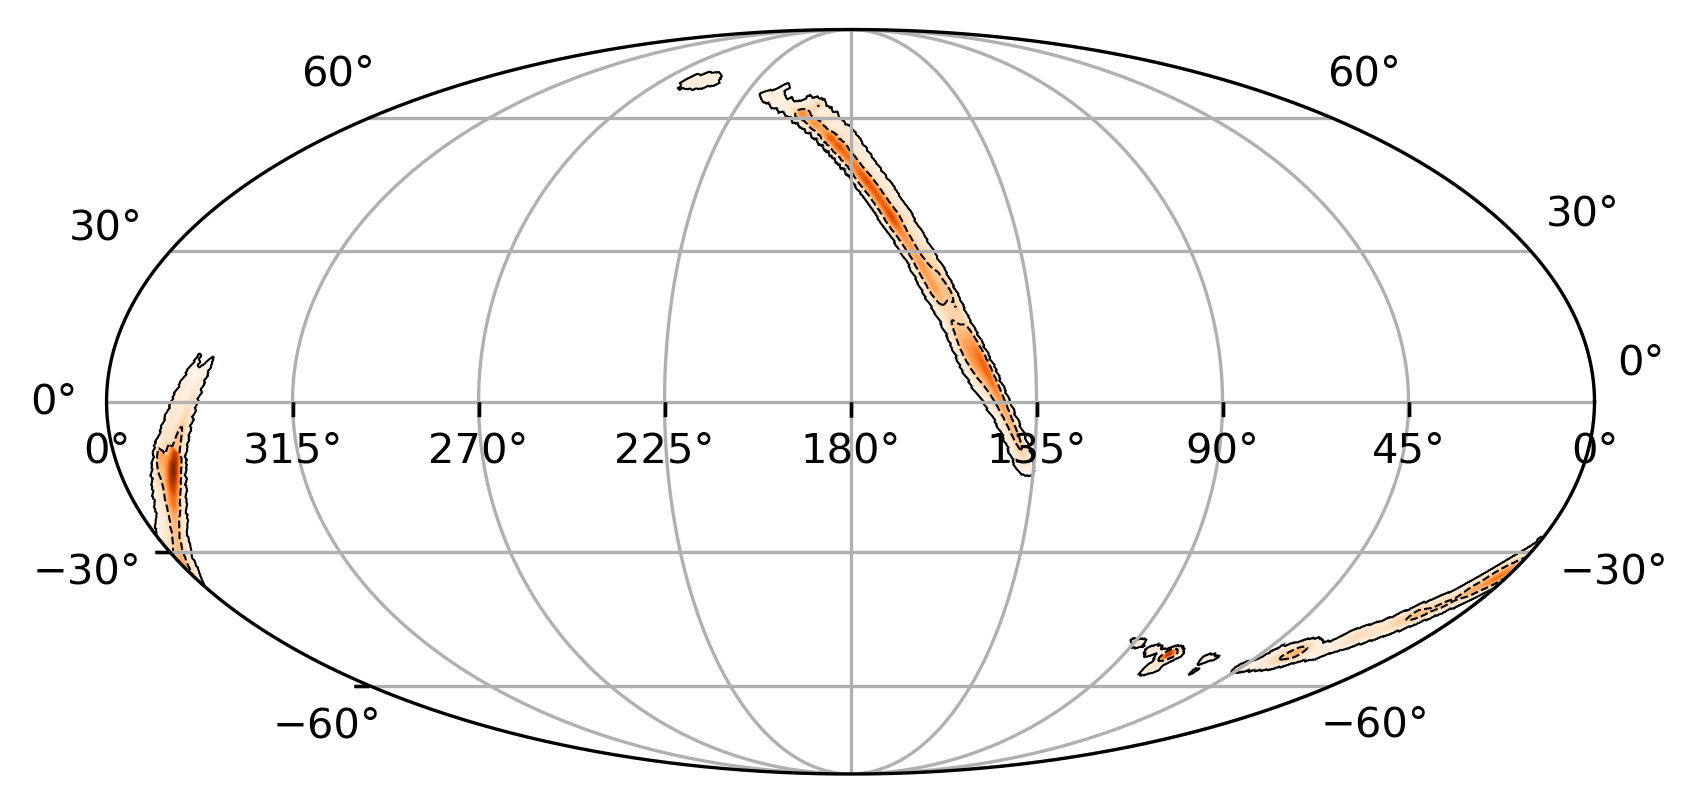

In [ ]:
import ligo.skymap.io.fits
import ligo.skymap.postprocess.util
import numpy as np
import matplotlib.pyplot as pp
from matplotlib.colors import LogNorm
from matplotlib import cm
import ligo.skymap.plot

skymap, _ = ligo.skymap.io.fits.read_sky_map('bayestar.fits', nest = True) # NEST = True ensures that the order is rearranged properly, both for flat and multi-order maps

fig = pp.figure(dpi=300)
ax = pp.axes(projection='astro degrees mollweide')
ax.grid()


cls = 100 * ligo.skymap.postprocess.util.find_greedy_credible_levels(skymap)

skymap[cls > 90] = np.nan
skymap[skymap == 0] = np.nan

ax.imshow_hpx((skymap, 'ICRS'), nested=True, cmap=cm.Oranges)
ax.contour_hpx((cls, 'ICRS'), nested=True, colors='black', levels=(50, 90), zorder=1, linestyles=['dashed', 'solid'], linewidths=0.5)

pp.show()

# Zoom

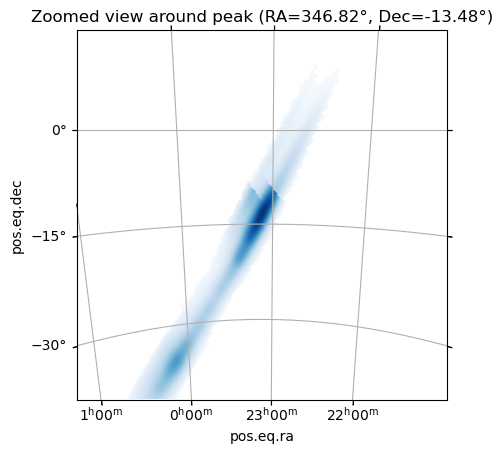

In [100]:
# Use the peak location from earlier
# Use the peak location from earlier
ax = plt.axes(projection='astro zoom',
              center=f'{ra_deg:.4f}d {dec_deg:.4f}d', radius='30 deg')
ax.grid()
ax.imshow_hpx((skymap, 'ICRS'), nested=True, cmap='Blues')

plt.title(f'Zoomed view around peak (RA={ra_deg:.2f}°, Dec={dec_deg:.2f}°)')
plt.show()

# Going in distance

Once we fix the position in the sky, the conditional posterior on distance is well approximated by a Gaussian times a uniform-in-volume prior.

$p(D_L | \text{RA, Dec}) = \text{DISTNORM(RA,Dec)} \times \exp\Big[-\dfrac{(D_L - \text{DISTMU(RA,Dec)})^2}{2 \text{DISTSTD(RA,Dec)}^2}\Big]\times D_L^2$